In [55]:
import numpy as np
import pandas as pd
import pyxdf
import mne

In [94]:
from pathlib import Path
xdf_path = Path(r"C:\Users\jshin\OW_closedloopLIFU\xdf_data\sub-dave_run_2\ses-1\eeg\sub-dave_run_2_ses-1_task-dave_run_2_run-001_eeg.xdf")
data, header = pyxdf.load_xdf(str(xdf_path))
for i, stream in enumerate(data):
    print(f"Stream {i}: {stream['info']['name'][0]}")

Stream 0: EEG_LIFU_events
Stream 1: PsychoPy_numeric
Stream 2: EEG_gpype
Stream 3: PsychoPyMarkers


In [95]:
def _load_streams():
    """Load all streams from the .xdf file and return by name."""
    #data, _ = pyxdf.load_xdf(str(XDF_PATH))
    return {s["info"]["name"][0]: s for s in data}
streams = _load_streams()
streams['EEG_LIFU_events']

{'info': defaultdict(list,
             {'name': ['EEG_LIFU_events'],
              'type': ['Markers'],
              'channel_count': ['1'],
              'channel_format': ['string'],
              'source_id': [None],
              'nominal_srate': ['0.000000000000000'],
              'version': ['1.100000000000000'],
              'created_at': ['2811637.357517600'],
              'uid': ['6300df14-0d63-45e3-bb45-f27785dbafa6'],
              'session_id': ['default'],
              'hostname': ['JanetsPC'],
              'v4address': [None],
              'v4data_port': ['16572'],
              'v4service_port': ['16572'],
              'v6address': [None],
              'v6data_port': ['16572'],
              'v6service_port': ['16572'],
              'desc': [None],
              'stream_id': 2,
              'effective_srate': 0,
              'segments': [(0, 117)],
              'clock_segments': [(0, 117)]}),
 'footer': {'info': defaultdict(list,
              {'first_times

In [96]:
stream = data[2]
df= []
df = pd.DataFrame(stream['time_series'])
df = df.rename(columns={i: f"Ch{i}" for i in range(df.shape[1])})

# Add timestamp column
df['Timestamp'] = stream['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in df.columns if col != 'Timestamp']
df = df[cols]
eeg_raw = df[['Ch0', 'Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch12','Timestamp']]
eeg_raw

,Ch0,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch12,Timestamp
0,-5197.716309,-9999.109375,-3748.226562,3159.284668,-2866.387939,7112.789062,-13532.520508,508.523041,2.811650e+06
1,-4532.313965,-9376.432617,-3339.839355,3736.305420,-2353.596924,7398.152344,-13149.596680,510.835693,2.811650e+06
2,-4534.149902,-9527.708008,-3229.475342,3741.765137,-2398.395752,7449.556152,-13214.398438,510.931061,2.811650e+06
3,-5197.454590,-10201.382812,-3630.185059,3173.923828,-2947.998047,7166.529785,-13616.466797,511.503265,2.811650e+06
4,-5281.139160,-10083.653320,-3786.850342,3092.265137,-2927.542236,7091.618652,-13583.065430,513.339172,2.811650e+06
...,...,...,...,...,...,...,...,...,...
66755,-4525.447754,-9560.348633,-5047.893555,2023.721069,-2443.433105,6835.056152,-14929.820312,513.839722,2.811917e+06
66756,-4568.506348,-9814.859375,-5031.729004,1994.204712,-2664.828857,6802.964844,-15067.554688,514.531128,2.811917e+06
66757,-4709.673340,-9645.843750,-5200.076660,1884.579834,-2535.748779,6772.780273,-14980.723633,513.005249,2.811917e+06
66758,-4677.010254,-9429.646484,-5202.269531,1897.573608,-2361.298096,6789.827148,-14884.854492,513.076843,2.811917e+06


In [97]:
trial_data = data[3]
# Create DataFrame from time_series
trial_df = pd.DataFrame(trial_data['time_series'])
trial_df
# Rename the first column to 'markers'
trial_df.rename(columns={0: 'markers'}, inplace=True)

# Add timestamp column
trial_df['Timestamp'] = trial_data['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in trial_df.columns if col != 'Timestamp']
trial_df = trial_df[cols]
trial_df

,Timestamp,markers
0,2.811701e+06,START_EXPERIMENT
1,2.811703e+06,START_EXPERIMENT
2,2.811705e+06,START_EXPERIMENT
3,2.811707e+06,START_EXPERIMENT
4,2.811709e+06,START_EXPERIMENT
...,...,...
95,2.811891e+06,START_EXPERIMENT
96,2.811893e+06,START_EXPERIMENT
97,2.811895e+06,START_EXPERIMENT
98,2.811897e+06,START_EXPERIMENT


In [98]:
lifu_on_ts = trial_df[trial_df['markers'] == 'LIFU_ON']
lifu_on_ts = lifu_on_ts['Timestamp']
lifu_on_ts.diff()

Series([], Name: Timestamp, dtype: float64)

In [99]:
trial_ts = np.array(trial_df['Timestamp'])
trial_ts

array([2811701.07281627, 2811703.06258472, 2811705.05636378,
       2811707.04970464, 2811709.042388  , 2811711.03590386,
       2811713.03755712, 2811715.03893068, 2811717.03229653,
       2811719.03437909, 2811721.03523015, 2811723.03687391,
       2811725.03831767, 2811727.03171393, 2811729.03377348,
       2811731.03489394, 2811733.0371701 , 2811735.03808466,
       2811737.03180722, 2811739.03358858, 2811741.03458644,
       2811743.036166  , 2811745.03781915, 2811747.03999691,
       2811749.03325147, 2811751.03434903, 2811753.03648449,
       2811755.03775335, 2811757.03978751, 2811759.03262246,
       2811761.03465182, 2811763.03614408, 2811765.03725814,
       2811767.039235  , 2811769.03214006, 2811771.03397661,
       2811773.03548737, 2811775.03700393, 2811777.03857029,
       2811779.03226125, 2811781.03339371, 2811783.03518517,
       2811785.03710763, 2811787.03882608, 2811789.03224314,
       2811791.0337734 , 2811793.03514466, 2811795.03667252,
       2811797.03876878,

In [100]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Match trial_ts (LSL timestamps) to closest sample index in eeg_raw
# ---------------------------------------------------------------------------
# Assumes:
#   - trial_ts: array-like of LSL timestamps to match (e.g. lifu_on, or any
#     other event-time array on the same LSL clock)
#   - eeg_raw:  DataFrame with a 'Timestamp' column (LSL time), same clock

timestamps = eeg_raw['Timestamp'].values
trial_ts = np.asarray(trial_ts)

# --- vectorized nearest-timestamp match ---
insert_idx = np.searchsorted(timestamps, trial_ts)
insert_idx = np.clip(insert_idx, 1, len(timestamps) - 1)

left_vals = timestamps[insert_idx - 1]
right_vals = timestamps[insert_idx]

use_left = np.abs(trial_ts - left_vals) < np.abs(trial_ts - right_vals)
matched_idx = np.where(use_left, insert_idx - 1, insert_idx)

# --- sanity check match quality ---
matched_time = timestamps[matched_idx]
time_diff = matched_time - trial_ts  # signed: negative = eeg sample before event, positive = after

fs = 1 / np.median(np.diff(timestamps))  # estimate actual sampling rate from data
expected_max_diff = 0.5 / fs  # half a sample period

n_bad = np.sum(np.abs(time_diff) > expected_max_diff)
if n_bad > 0:
    print(f"Warning: {n_bad} of {len(trial_ts)} matches exceed half a sample period "
          f"({expected_max_diff*1000:.2f} ms). Check for stream dropouts or clock offset.")
else:
    print(f"All {len(trial_ts)} matches within expected tolerance "
          f"({expected_max_diff*1000:.2f} ms), estimated fs = {fs:.2f} Hz.")

trial_index_df = pd.DataFrame({
    'trial_ts': trial_ts,
    'matched_index': matched_idx,
    'matched_timestamp': matched_time,
    'time_diff_sec': time_diff,
})
trial_index_df

All 100 matches within expected tolerance (2.00 ms), estimated fs = 249.98 Hz.


,trial_ts,matched_index,matched_timestamp,time_diff_sec
0,2.811701e+06,12759,2.811701e+06,0.000656
1,2.811703e+06,13256,2.811703e+06,-0.000938
2,2.811705e+06,13755,2.811705e+06,0.001459
3,2.811707e+06,14253,2.811707e+06,0.000293
4,2.811709e+06,14751,2.811709e+06,-0.000215
...,...,...,...,...
95,2.811891e+06,60244,2.811891e+06,-0.000848
96,2.811893e+06,60745,2.811893e+06,0.001710
97,2.811895e+06,61245,2.811895e+06,0.000178
98,2.811897e+06,61745,2.811897e+06,-0.001547


In [101]:
trials = np.array(trial_index_df['matched_index'])
#trials = trials[1:]
trials

array([12759, 13256, 13755, 14253, 14751, 15249, 15750, 16250, 16748,
       17249, 17749, 18249, 18750, 19248, 19748, 20249, 20749, 21249,
       21748, 22248, 22748, 23249, 23749, 24250, 24748, 25248, 25749,
       26249, 26749, 27248, 27748, 28248, 28749, 29249, 29747, 30248,
       30748, 31248, 31749, 32247, 32747, 33248, 33748, 34248, 34747,
       35247, 35747, 36248, 36748, 37246, 37747, 38247, 38748, 39248,
       39746, 40247, 40747, 41247, 41748, 42248, 42746, 43247, 43747,
       44247, 44748, 45246, 45746, 46247, 46747, 47247, 47746, 48246,
       48746, 49247, 49747, 50245, 50746, 51246, 51746, 52247, 52745,
       53246, 53746, 54246, 54746, 55247, 55745, 56246, 56746, 57246,
       57744, 58245, 58745, 59246, 59746, 60244, 60745, 61245, 61745,
       62246])

Creating RawArray with float64 data, n_channels=7, n_times=66760


    Range : 0 ... 66759 =      0.000 ...   267.036 secs


Ready.


Filtering raw data in 1 contiguous segment


Setting up band-pass filter from 1 - 40 Hz


...

Applying a custom ('EEG',) reference.


Fitting ICA to data using 7 channels (please be patient, this may take a while)


Selecting by explained variance: 6 components


C:\Users\jshin\AppData\Local\Temp\ipykernel_19860\2393256228.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


Fitting ICA took 0.2s.


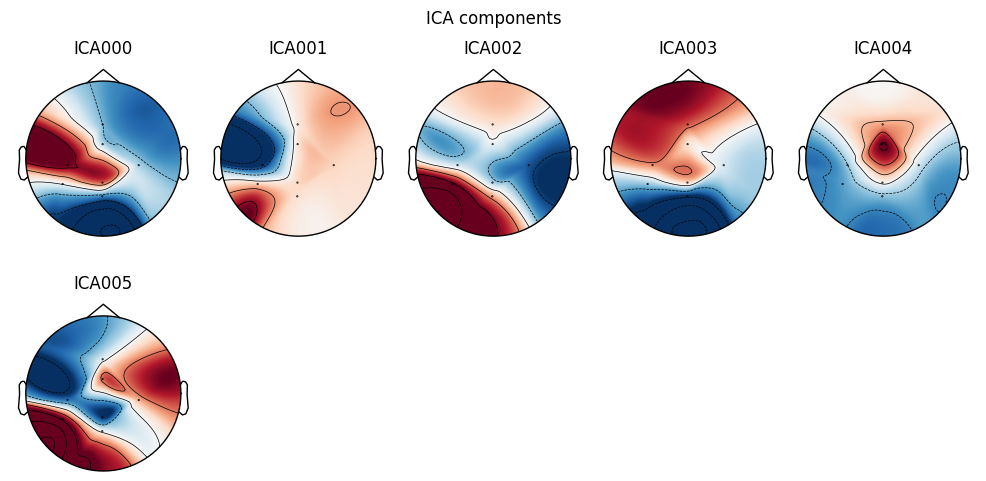

Creating RawArray with float64 data, n_channels=6, n_times=66760


    Range : 0 ... 66759 =      0.000 ...   267.036 secs


Ready.


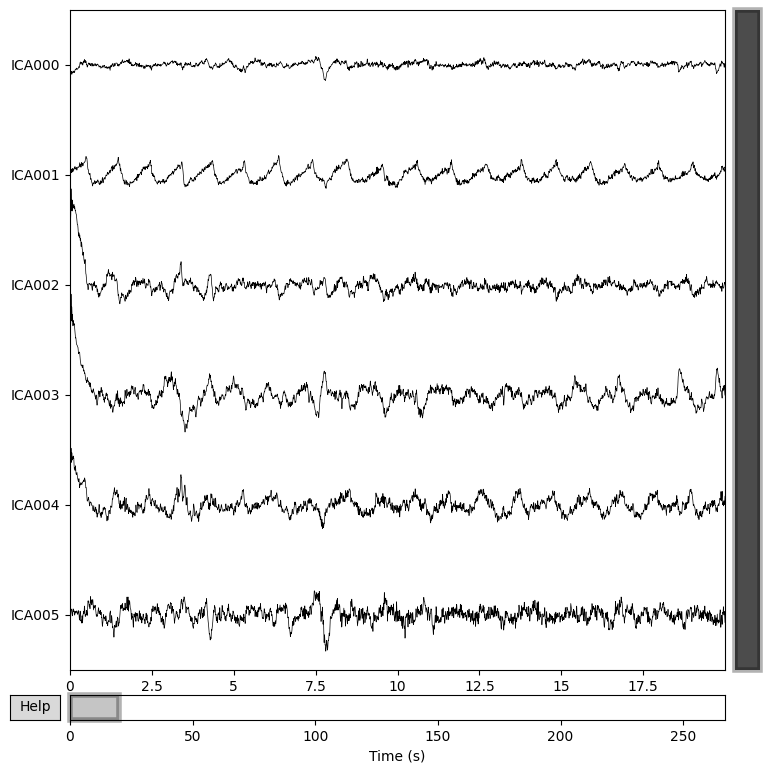

Applying ICA to Raw instance


    Transforming to ICA space (6 components)


    Zeroing out 3 ICA components


    Projecting back using 7 PCA components


In [102]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# first_data: rows = samples, columns = 8 EEG channels
# 1. Clean and Load Data

df = pd.DataFrame(eeg_raw.copy())
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
df = df.interpolate(method='linear', limit=5, limit_direction='both')
df = df.fillna(method='bfill').fillna(method='ffill')
df.drop(['Timestamp', 'Ch12'], axis = 1, inplace = True)

# 2. MNE Array Building
sfreq = 250
data = df.values.T  # shape: (n_channels, n_samples)

# Mapping
ch_names = [
    "FCz",   # 1
    "CP3",   # 2
    "P5",  # 3
    "Cz",   # 4
    "Pz",   # 5
    "POz",  # 6
    "CP4",  # 7
    #"F5"    # 8
]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# 3. ICA topography
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# 4. Filtering
# 1–40 Hz is a good compromise for ICA + PSD
raw.filter(1., 40., fir_design='firwin')
raw.notch_filter(60.)
#raw.filter(l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming')
raw.set_eeg_reference('average')

# 5. ICA
ica = mne.preprocessing.ICA(
    n_components= 0.99999,
    random_state=97,
    max_iter='auto'
)
ica.fit(raw)

# Inspect components:
ica.plot_components()      # scalp maps
ica.plot_sources(raw)      # time series

# After inspecting, set the components you want to remove:
ica.exclude = [0,2,4]  # don't know how to do this
raw_clean = ica.apply(raw.copy())


In [103]:
# lifu_on_time_onset is an array of times in seconds
event_samples = trials

# Build MNE event array: shape (n_events, 3)
# Columns: [sample_index, 0, event_id]
events = np.column_stack([event_samples, 
                          np.zeros_like(event_samples, dtype=int), 
                          np.ones_like(event_samples, dtype=int)])
tmin = -0.2
tmax = 0.8

epochs = mne.Epochs(
    raw,
    events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    baseline=(-0.2, 0),     # or (-2, 0) if you want baseline correction
    preload=True
)

Not setting metadata


100 matching events found


Applying baseline correction (mode: mean)


0 projection items activated


Using data from preloaded Raw for 100 events and 251 original time points ...


0 bad epochs dropped


In [104]:
erp = epochs.average()
erp

<Evoked | '1' (average, N=100), -0.2 – 0.8 s, baseline -0.2 – 0 s, 7 ch, ~29 KiB>

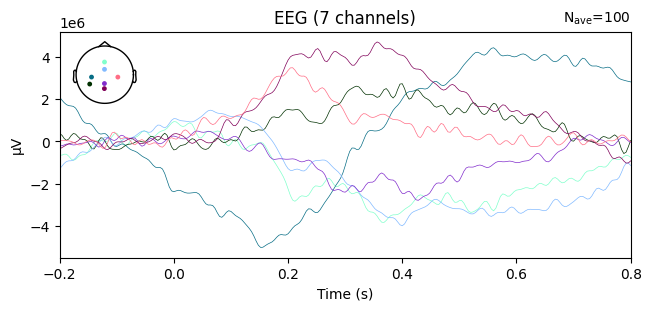

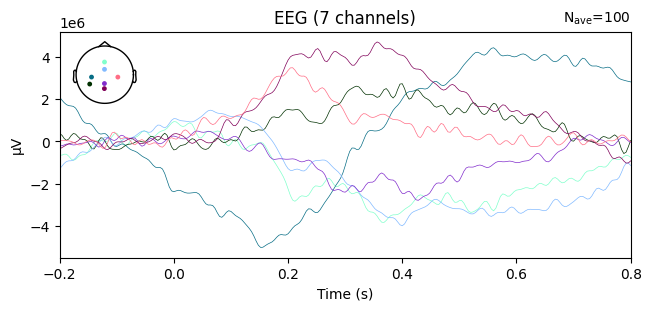

In [105]:
erp.plot()

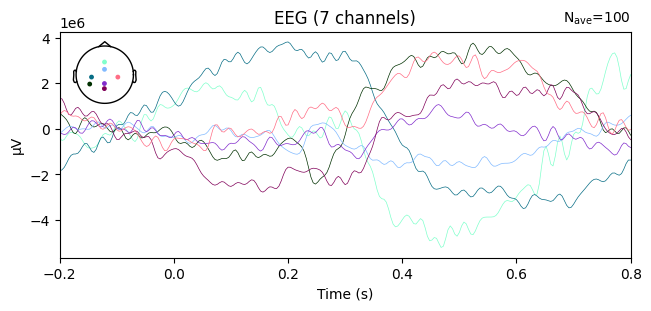

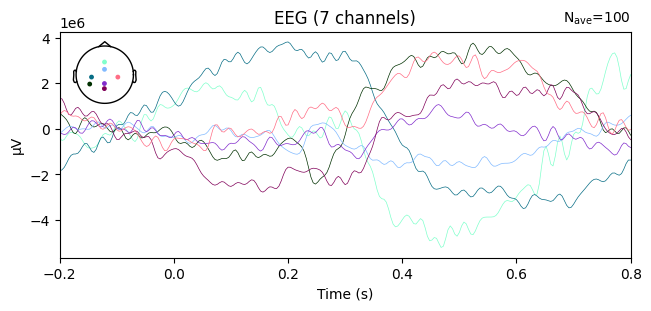